# Kilonova Simulation


Kilonovae evolve rapidly, the SED moves hard to the red, and ZShooter will observe early and late in the
sequence.

See e.g. Kasen et al. 2017 synthetic kilonova spectra, plus one observed sequence panel from GW170817-era follow-up.


## Set up Simulator

```
1. UserCommands(use_instrument=..., set_modes=[...])
        └─ parse default.yaml + mode yamls, build rc config
```

In [1]:
import matplotlib.pyplot as plt
from astropy import units as u
import scopesim as sim
import scopesim_templates as sim_tp
import importlib.resources
import pathlib
import numpy as np

from spextra import Spextrum
import synphot
import astropy.units as u
from scopesim.source.source import Source

def plot_source(source):
    wave = np.linspace(0.3, 2.5, 1001) * u.um
    num_fields = len(source.fields)
    fig, axs = plt.subplots(figsize=(6,2*num_fields), nrows=num_fields, ncols=2, width_ratios=[1,2], constrained_layout=True)
    if num_fields == 1:
        axs = np.array([axs])
    for i, field in enumerate(source.fields):
        ax1, ax2 = axs[i]
        if hasattr(field, 'data'):
            ax1.imshow(field.data, origin='lower', cmap='viridis')
        elif hasattr(field, 'field') and all(col in field.field.colnames for col in ('x', 'y')):
            ax1.scatter(field.field['x'], field.field['y'], s=30)
            ax1.set_aspect('equal', adjustable='box')
        else:
            ax1.text(0.5, 0.5, field.__class__.__name__, ha='center', va='center')
        ax2.plot(wave, field.spectrum(wave))
        ax1.set_title('Spatial Profile')
        ax1.set_xlabel('X (arcsec)')
        ax1.set_ylabel('Y (arcsec)')
        ax2.set_title('Spectrum')
        ax2.set_xlabel('Wavelength (um)')
        ax2.set_ylabel(r'Flux (ph s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)')

## configure IRDB path
try:
    irdb_path = str(pathlib.Path(importlib.resources.files('irdb')).parent)
except ModuleNotFoundError:
    irdb_path = str(pathlib.Path.home() / "src" / "irdb")

sim.rc.__config__["!SIM.file.local_packages_path"] = irdb_path
sim.rc.__config__["!SIM.file.search_path"].append(irdb_path)

## configure logging level
sim.utils.set_console_log_level("DEBUG")  ## INFO, DEBUG, WARNING, ERROR, CRITICAL

## user commands
cmd = sim.UserCommands(use_instrument="ZShooter_v2", set_modes=["SPEC"])

## Set Settings

In [2]:
cmd['!OBS.brightness'] = 'bright'
cmd['!OBS.airmass']=2.0

## Create ZShooter's OpticalTrain

```
2. OpticalTrain(cmd)
        ├─ OpticsManager loads all yaml effects into optical elements
        ├─ FOVManager runs z_order 200–299 effects → FovVolumeList
        ├─ ImagePlane objects initialised from z_order 100–199 / 400–499
        └─ DetectorManager creates Detector objects from z_order 400–499 effects
```

In [3]:
zs = sim.OpticalTrain(cmd)

astar.scopesim.utils - Using !OBS.brightness bright for observation time
astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.utils - Setting obstime to midnight of the same day. New UTC time is 2026-07-29T10:21:53.856.
astar.scopesim.utils - WARNING: Target coord !OBS.alt not set in !OBS config.
astar.scopesim.utils - WARNING: Target coord !OBS.ra not set in !OBS config.
astar.scopesim.utils - WARNING: Target coord !OBS.dec not set in !OBS config.
astar.scopesim.utils - Setting coordinates from alt/airmass, location and obstime input.
astar.scopesim.effects.sky_ter_curves - WARNING: wmin 299.99999999999994 is below the minimum wavelength covered by SkyCalc. Setting to 300 nm.
astar.scopesim.utils - Using !OBS.brightness bright for observation time
astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.utils - Setting obstime to midnight of the same day. New UTC time is 2026-07-29T10:21:53.856.
astar.scopesim.utils - WARNING: Target coord !OB

## Set Other Settings

## Create a scene

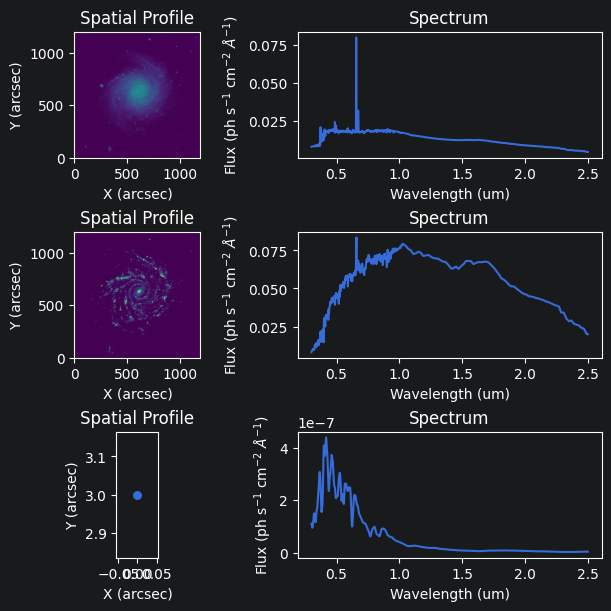

<Figure size 640x480 with 0 Axes>

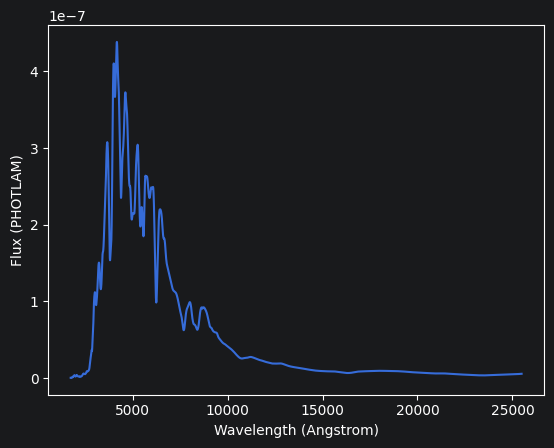

<Figure size 640x480 with 0 Axes>

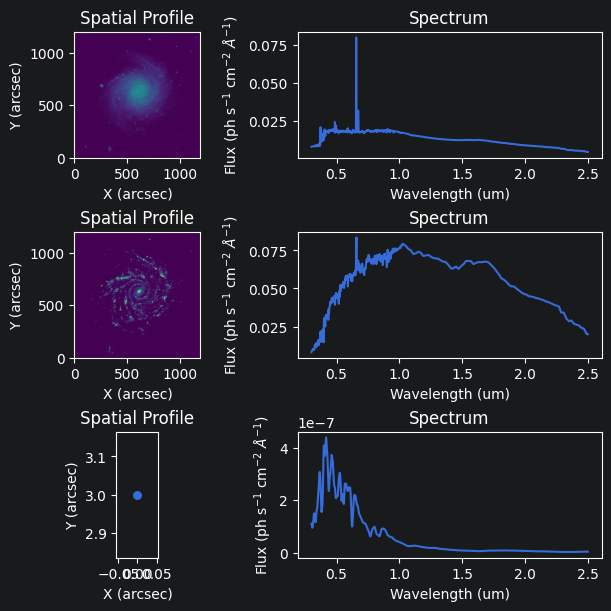

In [4]:
spectrum_file = None


# Start with a Galaxy off to the side
scene = sim_tp.extragalactic.galaxies.spiral_two_component(extent=200*u.arcsec, fluxes=(20, 20)*u.mag)  # loaded from saved fits template of NGC1232L
scene.shift(dy=-30*0.004)


# download spectrum from spextra library

sed = Spextrum('sne/sn1a').redshift(0.02) # redshift it to match the host galaxy
spec = sed.scale_to_magnitude(24*u.ABmag, 'g')


# add sn to scene 3" above center
scene.append(Source(spectra=spec, x=[0.0], y=[3.0], ref=[0.], weight=[1.0]))

# optionally add a user spectrum file to scene -3" above center
if spectrum_file:
    user_spec = synphot.SourceSpectrum.from_file(spectrum_file)
    scene.append(Source(spectra=user_spec, x=[0.0], y=[-3.0], ref=[0.], weight=[1.0]))

plot_source(scene)
plt.figure()
spec.plot()
plt.figure()
plot_source(scene)

### Observe It
```
3. observe(source)
        ├─ z_order 500–599: source-level spectral transmission applied
        ├─ For each FoV:
        │     ├─ Extract overlapping source data → attach to FoV
        │     └─ z_order 600–699: 3D FOV effects (PSF, trace, ADC, shifts…)
        ├─ Project FoV HDU → correct ImagePlane
        └─ z_order 700–799: 2D image plane effects
```

Note that some final settings can be set here. The locations of settings varies due to ..... Best practice is to ...., think of them as settings of category ....

In [5]:
kwargs = {'exposure_time': 1000*u.ms, 'n_exposures': 1}  ## Final sewttings

zs.observe(scene, **kwargs)

astar.scopesim.optics.fov_manager - Generating initial fovs_list.
astar.scopesim.effects.ter_curves - Executing dichroic_tree, FoV setup
astar.scopesim.effects.ter_curves - Created 1 FoVs for aperture_id 0
astar.scopesim.effects.ter_curves - Created 1 FoVs for aperture_id 1
astar.scopesim.effects.ter_curves - Created 1 FoVs for aperture_id 2
astar.scopesim.effects.ter_curves - Created 1 FoVs for aperture_id 3
astar.scopesim.effects.ter_curves - Created 1 FoVs for aperture_id 4
astar.scopesim.effects.ter_curves - Created 1 FoVs for aperture_id 5
astar.scopesim.effects.selector_wheel - Applying effect for aperture_id: 0 -> SlitWheel: "<empty> : [0.7]", volumes: 1
astar.scopesim.effects.apertures - Executing 0.7, FoV setup
astar.scopesim.effects.selector_wheel - Applying effect for aperture_id: 1 -> SlitWheel: "<empty> : [0.7]", volumes: 1
astar.scopesim.effects.apertures - Executing 0.7, FoV setup
astar.scopesim.effects.selector_wheel - Applying effect for aperture_id: 2 -> SlitWheel: "<

 FOVs:   0%|          | 0/130 [00:00<?, ?it/s]

astar.scopesim.optics.fov - 7 fields in FOV
astar.scopesim.optics.fov - old naxis: [1200, 1200]
astar.scopesim.optics.fov - Found 'deg' in image WCS, applying 360 fix.
astar.scopesim.optics.fov - XY HDU:
[[-0.02777778 -0.02781111]
 [-0.02777778  0.02774444]
 [ 0.02777778  0.02774444]
 [ 0.02777778 -0.02781111]]
astar.scopesim.optics.fov - XY FOV:
[[-1.37662222e-03 -7.56222222e-05]
 [-1.37662222e-03  9.72222222e-05]
 [ 1.38888889e-03  9.72222222e-05]
 [ 1.38888889e-03 -7.56222222e-05]]
astar.scopesim.optics.fov - xy0s: [-1.37662222e-03 -7.56222222e-05]; xy1s: [1.38888889e-03 9.72222222e-05]
astar.scopesim.optics.fov - xyp:
[[569.76496 598.58656]
 [629.5     602.32   ]]
astar.scopesim.optics.fov - xyp:
[[569.76496 598.58656]
 [629.5     602.32   ]]
astar.scopesim.optics.fov - xy0p: [569 598]; xy1p: [630 603]
astar.scopesim.optics.fov - xy0p: [569 598]; xy1p: [630 603]
astar.scopesim.optics.fov - old naxis: [1200, 1200]
astar.scopesim.optics.fov - Found 'deg' in image WCS, applying 360 fi

 FOV effects:   0%|          | 0/8 [00:00<?, ?it/s]

astar.scopesim.effects.psfs.psf_base - Executing seeing_psf, convolution
astar.scopesim.effects.psfs.psf_base - PSF convolution start
astar.scopesim.effects.psfs.psf_base - PSF convolution done
astar.scopesim.effects.atmo_dispersion - Residuals supplied by adc_residuals.dat
astar.scopesim.effects.atmo_dispersion - Additional residual from zenith angle error: 0.1
astar.scopesim.utils - Using !OBS.brightness bright for observation time
astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.utils - Setting obstime to midnight of the same day. New UTC time is 2026-07-29T10:21:53.856.
astar.scopesim.utils - WARNING: Target coord !OBS.alt not set in !OBS config.
astar.scopesim.utils - WARNING: Target coord !OBS.ra not set in !OBS config.
astar.scopesim.utils - WARNING: Target coord !OBS.dec not set in !OBS config.
astar.scopesim.utils - Setting coordinates from alt/airmass, location and obstime input.
astar.scopesim.effects.atmo_dispersion - Direction of zenith, measured

...

astar.scopesim.effects.psfs.psf_base - Executing seeing_psf, convolution
astar.scopesim.effects.psfs.psf_base - PSF convolution start
astar.scopesim.effects.psfs.psf_base - PSF convolution done
astar.scopesim.effects.atmo_dispersion - Residuals supplied by adc_residuals.dat
astar.scopesim.effects.atmo_dispersion - Additional residual from zenith angle error: 0.1
astar.scopesim.effects.atmo_dispersion - Direction of zenith, measured counter-clockwise from +y axis is -179.
astar.scopesim.effects.ter_curves - Executing dichroic_tree, observe
astar.scopesim.effects.spectral_trace_list - trace_list_analytical applied to FieldOfView3D
astar.scopesim.effects.spectral_trace_list_utils - Mapping k_35
astar.scopesim.effects.spectral_trace_list - trace_list_analytical done
astar.scopesim.optics.fov - 7 fields in FOV
astar.scopesim.optics.fov - old naxis: [1200, 1200]
astar.scopesim.optics.fov - Found 'deg' in image WCS, applying 360 fix.
astar.scopesim.optics.fov - XY HDU:
[[-0.02777778 -0.027811

 FOV effects:   0%|          | 0/8 [00:00<?, ?it/s]

astar.scopesim.effects.psfs.psf_base - Executing seeing_psf, convolution
astar.scopesim.effects.psfs.psf_base - PSF convolution start
astar.scopesim.effects.psfs.psf_base - PSF convolution done
astar.scopesim.effects.atmo_dispersion - Residuals supplied by adc_residuals.dat
astar.scopesim.effects.atmo_dispersion - Additional residual from zenith angle error: 0.1
astar.scopesim.effects.atmo_dispersion - Direction of zenith, measured counter-clockwise from +y axis is -179.
astar.scopesim.effects.ter_curves - Executing dichroic_tree, observe
astar.scopesim.effects.spectral_trace_list - trace_list_analytical applied to FieldOfView3D
astar.scopesim.effects.spectral_trace_list_utils - Mapping k_36
astar.scopesim.effects.spectral_trace_list - trace_list_analytical done
astar.scopesim.optics.fov - 7 fields in FOV
astar.scopesim.optics.fov - old naxis: [1200, 1200]
astar.scopesim.optics.fov - Found 'deg' in image WCS, applying 360 fix.
astar.scopesim.optics.fov - XY HDU:
[[-0.02777778 -0.027811

 FOV effects:   0%|          | 0/8 [00:00<?, ?it/s]

astar.scopesim.effects.psfs.psf_base - Executing seeing_psf, convolution
astar.scopesim.effects.psfs.psf_base - PSF convolution start
astar.scopesim.effects.psfs.psf_base - PSF convolution done
astar.scopesim.effects.atmo_dispersion - Residuals supplied by adc_residuals.dat
astar.scopesim.effects.atmo_dispersion - Additional residual from zenith angle error: 0.1
astar.scopesim.effects.atmo_dispersion - Direction of zenith, measured counter-clockwise from +y axis is -179.
astar.scopesim.effects.ter_curves - Executing dichroic_tree, observe
astar.scopesim.effects.spectral_trace_list - trace_list_analytical applied to FieldOfView3D
astar.scopesim.effects.spectral_trace_list_utils - Mapping k_37
astar.scopesim.effects.spectral_trace_list - trace_list_analytical done


## Read It Out

```
4. readout()
        ├─ Map ImagePlane → Detector
        ├─ z_order 800–899: detector effects (noise, dark, readout)
        ├─ z_order 900–999: detector array effects
        └─ z_order 1000–1099: FITS header effects → return list of HDUs
```

In [7]:
import datetime
instrument = cmd["!OBS.instrument"]
mode = "_".join(cmd["!OBS.modes"])
scene_name = cmd["!OBS.object"]
file_root = f"./{instrument}_{mode}-{scene_name}_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}"
file = f"{file_root}.fits"

hdus = zs.readout(file)

astar.scopesim.optics.optical_train - exptime: None given in kwargs, put in !OBS
astar.scopesim.optics.optical_train - dit: None given in kwargs, put in !OBS
astar.scopesim.optics.optical_train - ndit: None given in kwargs, put in !OBS
astar.scopesim.detector.detector_manager - Extracting from 1 detectors...
astar.scopesim.effects.selector_wheel - Since passed object is a Detector, selector_key by default is the ID of the Detector object.
astar.scopesim.effects.electronic - ExposureIntegration.: DIT = 300.0 s, NDIT = 1
astar.scopesim.effects.selector_wheel - Since passed object is a Detector, selector_key by default is the ID of the Detector object.
astar.scopesim.effects.selector_wheel - Since passed object is a Detector, selector_key by default is the ID of the Detector object.
astar.scopesim.effects.selector_wheel - Since passed object is a Detector, selector_key by default is the ID of the Detector object.
astar.scopesim.effects.selector_wheel - Since passed object is a Detector, s

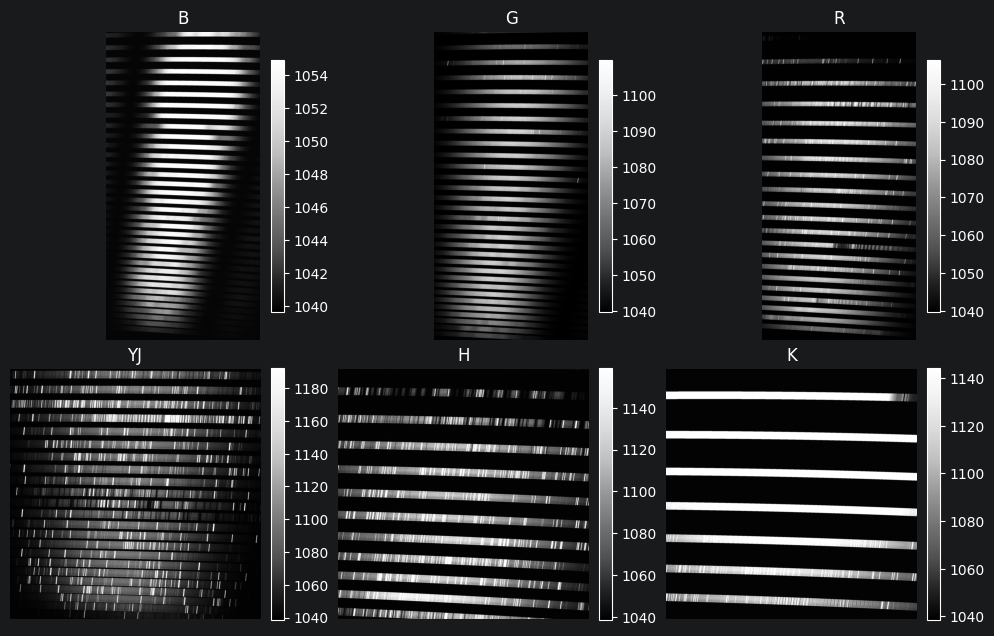

In [8]:
from astropy.visualization import ZScaleInterval

# reduce space between subplots
fig, axes = plt.subplots(2,3, figsize=(12,8), gridspec_kw={'wspace':0.2}, tight_layout=True)
titles = ['B', 'G', 'R', 'YJ', 'H', 'K']
i = 0
for ax, imhdu in zip(axes.flat, hdus):
    interval = ZScaleInterval()
    vmin, vmax = interval.get_limits(imhdu[1].data)
    ax.axis("off")
    im = ax.imshow(imhdu[1].data, origin='lower', vmin=vmin, vmax=vmax, cmap='Grays_r')
    ax.set_title(titles[i])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    i += 1

plt.subplots_adjust(wspace=0.0, hspace=0.0)